# Kinematic Figure Notebook

Interactive notebook for WT Figure 2 and the T2 IT/OT and T1 BO/NB analyses. Run the setup cells first, then enable only the figure cells you need.

## 1. Environment setup

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
from IPython.display import IFrame, display
import itertools
import sys

import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "KinematicPlot.py").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Repository root: {ROOT}")
print(f"Python executable: {sys.executable}")

Repository root: C:\Users\agrawal-admin\Desktop\New folder
Python executable: C:\Users\agrawal-admin\anaconda3\envs\DailyTask\python.exe


In [2]:
import KinematicPlot as kp
from group_config_new import build_groups
from survival_stats_runner import SurvivalStatsRunner

FIGURES_DIR = ROOT / "Figures"
SC_DATA_DIR = ROOT / "SC data"
OTHER_LANDING_DATA_DIR = ROOT / "LandingData" / "Others"
NOTEBOOK_OUTPUT_DIR = FIGURES_DIR / "KinematicPlotNoteBook"
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

N_PERM = 20000  # Reduce to 1000 while testing code or figure layout.

plotter = kp.PlotCreator(
    platform_offset=0.07,
    platform_height=0.1,
    radius=0.03,
    fps=250,
)

stats_runner = SurvivalStatsRunner(
    tau=0.71,
    random_state=0,
    platform_offset=0.03,
    radius=0.07,
    fps=250,
)

def output_folder(*parts):
    folder = NOTEBOOK_OUTPUT_DIR.joinpath(*parts)
    folder.mkdir(parents=True, exist_ok=True)
    return folder

def show_pdf(path, width=950, height=700):
    path = Path(path)
    try:
        source = path.relative_to(ROOT).as_posix()
    except ValueError:
        source = path.as_posix()
    display(IFrame(src=source, width=width, height=height))

print(f"Notebook outputs: {NOTEBOOK_OUTPUT_DIR}")

Notebook outputs: C:\Users\agrawal-admin\Desktop\New folder\Figures\KinematicPlotNoteBook


## 2. Build the required groups

This creates the six WT group objects used by Figure 2. Kinematic CSV files are loaded later by the individual plotting functions.

In [3]:
required_group_keys = [
    "WT_T1_TTa", "WT_T1_CTF",
    "WT_T2_TTa", "WT_T2_CTF",
    "WT_T3_TTa", "WT_T3_CTF",
]

groups = build_groups(
    group_keys=required_group_keys,
    skip_missing=False,
    require_kinematics=False,
)

pd.DataFrame([
    {
        "Config_Key": key,
        "Group_Name": group.group_name,
        "Metadata_Loaded": len(group.trial_metadata),
        "Kinematic_Trials_Loaded": len(group.fly_kinematic_data),
    }
    for key, group in groups.items()
])

,Config_Key,Group_Name,Metadata_Loaded,Kinematic_Trials_Loaded
0,WT_T1_TTa,WT-T1-TiTa,0,0
1,WT_T1_CTF,WT-T1-CxTr,0,0
2,WT_T2_TTa,WT-T2-TiTa,0,0
3,WT_T2_CTF,WT-T2-CxTr,0,0
4,WT_T3_TTa,WT-T3-TiTa,0,0
5,WT_T3_CTF,WT-T3-CxTr,0,0


In [4]:
wt_tita_groups = {
    "T1": groups["WT_T1_TTa"],
    "T2": groups["WT_T2_TTa"],
    "T3": groups["WT_T3_TTa"],
}
wt_cxtr_groups = {
    "T1": groups["WT_T1_CTF"],
    "T2": groups["WT_T2_CTF"],
    "T3": groups["WT_T3_CTF"],
}
wt_tita_sc_paths = {
    "T1": SC_DATA_DIR / "WT-T1-TiTa_LegContact.csv",
    "T2": SC_DATA_DIR / "WT-T2-TiTa_LegContact.csv",
    "T3": SC_DATA_DIR / "WT-T3-TiTa_LegContact.csv",
}
wt_tita_manual_sc_legs = {
    "T1": ("L-f", "L-m", "L-h", "R-m", "R-h"),
    "T2": ("L-f", "L-m", "L-h", "R-f", "R-h"),
    "T3": ("L-f", "L-m", "L-h", "R-f", "R-m"),
}

wt_groups_ordered = [
    groups["WT_T1_TTa"], groups["WT_T1_CTF"],
    groups["WT_T2_TTa"], groups["WT_T2_CTF"],
    groups["WT_T3_TTa"], groups["WT_T3_CTF"],
]
wt_group_colors = {
    "WT-T1-TiTa": "#1f77b4",
    "WT-T1-CxTr": "#8ecae6",
    "WT-T2-TiTa": "#d62728",
    "WT-T2-CxTr": "#ff9896",
    "WT-T3-TiTa": "#2ca02c",
    "WT-T3-CxTr": "#98df8a",
}
wt_group_markers = {group.group_name: "o" for group in wt_groups_ordered}
wt_group_linestyles = {group.group_name: "solid" for group in wt_groups_ordered}

# Figure 2: WT Data

## Figure 2A: Landing probability

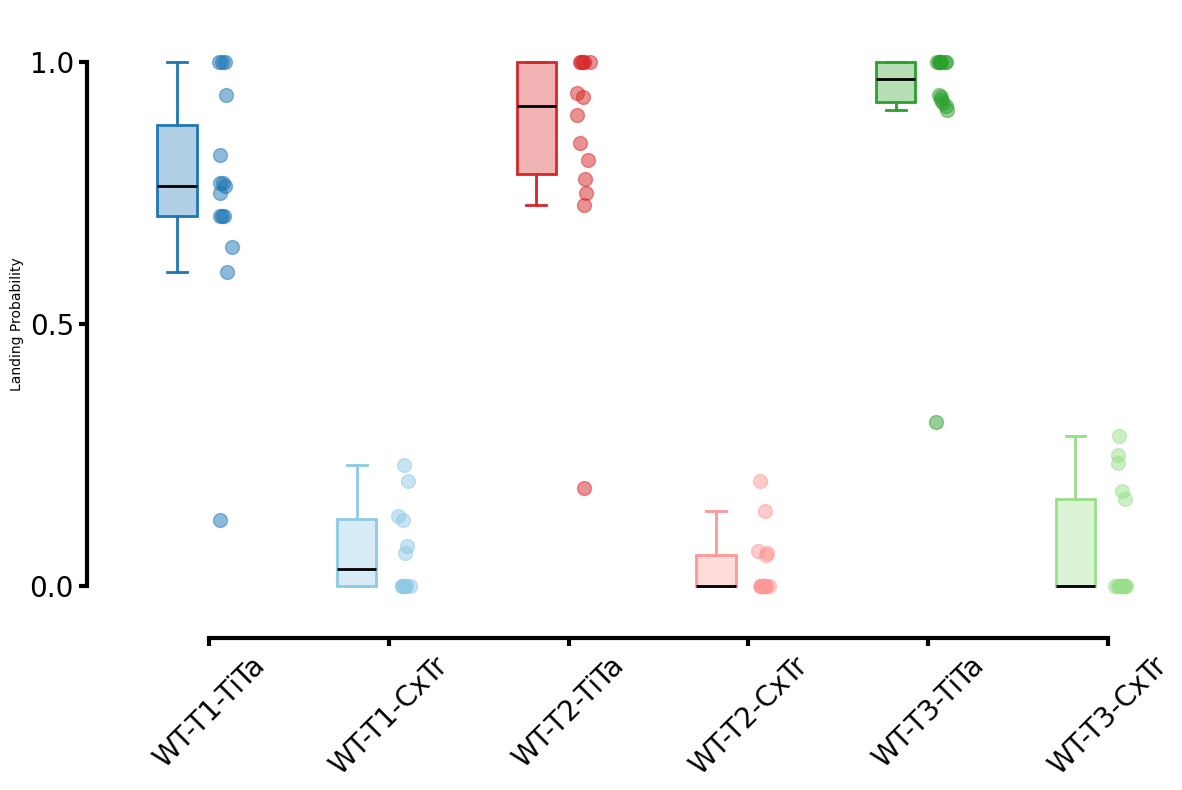

In [5]:
RUN_FIGURE_2A = True

if RUN_FIGURE_2A:
    out = output_folder("WT_Figure_2", "2A_landing_probability")
    pdf = out / "Figure_2A_WT_landing_probability.pdf"

    plotter.plot_LP_summary_from_groups(
        groups=wt_groups_ordered,
        file_name=str(pdf.with_suffix("")),
        colors=wt_group_colors,
        markers=wt_group_markers,
    )

    stat_rows = []
    for group_a, group_b in itertools.combinations(wt_groups_ordered, 2):
        prefix = out / f"Figure_2A_{group_a.group_name}_vs_{group_b.group_name}_LP"
        result, _ = stats_runner.compare_lp_unpaired(
            group_a=group_a,
            group_b=group_b,
            out_prefix=str(prefix),
            n_perm=N_PERM,
        )
        stat_rows.append(result)
    pd.concat(stat_rows, ignore_index=True).to_csv(
        out / "Figure_2A_WT_landing_probability_pairwise_stats.csv",
        index=False,
    )
    # show_pdf(pdf)

## Figure 2B: Inverted landing-latency KM curves

In [6]:
RUN_FIGURE_2B = True

if RUN_FIGURE_2B:
    out = output_folder("WT_Figure_2", "2B_landing_latency_KM")
    pdf = out / "Figure_2B_WT_landing_latency_inverted_KM-LL-KMC-flipped.pdf"

    plotter.plot_KM_curve_from_groups(
        groups=wt_groups_ordered,
        file_name=str(pdf.with_suffix("")),
        colors=wt_group_colors,
        linestyles=wt_group_linestyles,
        markers={group.group_name: None for group in wt_groups_ordered},
    )

    stat_rows = []
    for group_a, group_b in itertools.combinations(wt_groups_ordered, 2):
        prefix = out / f"Figure_2B_{group_a.group_name}_vs_{group_b.group_name}_LL"
        result, _ = stats_runner.analyze_landing_unpaired(
            group_a=group_a,
            group_b=group_b,
            out_prefix=str(prefix),
            n_perm=N_PERM,
        )
        stat_rows.append(result)
    pd.concat(stat_rows, ignore_index=True).to_csv(
        out / "Figure_2B_WT_landing_latency_pairwise_fly_RMST_stats.csv",
        index=False,
    )
    show_pdf(pdf)

## Figure 2C: Contacted-leg CT and FT angle traces

In [7]:
RUN_FIGURE_2C = True

if RUN_FIGURE_2C:
    out = output_folder("WT_Figure_2", "2C_CT_FT_angle_traces")
    pdf = out / "Figure_2C_WT_CT_FT_angle_traces.pdf"
    plotter.plot_wt_contact_group_angle_traces(
        groups_by_column={"TiTa": wt_tita_groups, "CxTr": wt_cxtr_groups},
        file_name=str(pdf.with_suffix("")),
        contact_leg_map={"T1": "R-f", "T2": "R-m", "T3": "R-h"},
        contact_colors={"T1": "#1f77b4", "T2": "#d62728", "T3": "#2ca02c"},
        start_s=-0.1,
        end_s=0.71,
        target_fps=250,
        trial_types=("Landing", "Flying"),
        show_sem=True,
    )
    show_pdf(pdf)

## Figure 2D: Manual SC timing inverted KM curves and RMST tests

In [8]:
RUN_FIGURE_2D = True

if RUN_FIGURE_2D:
    out = output_folder("WT_Figure_2", "2D_manual_SC_KM")
    generated_pdfs = []
    for contact_group, group_info in wt_tita_groups.items():
        prefix = out / f"Figure_2D_WT_{contact_group}_TiTa_manual_SC_inverted_KM"
        plotter.plot_manual_sc_inverted_km_from_csv(
            group_info=group_info,
            sc_csv_path=wt_tita_sc_paths[contact_group],
            legs=wt_tita_manual_sc_legs[contact_group],
            threshold=0.71,
            file_name=str(prefix),
        )
        generated_pdfs.extend([
            Path(f"{prefix}_all_trials.pdf"),
        ])

    plotter.compare_manual_sc_rmst_across_contact_groups(
        group_infos=wt_tita_groups,
        sc_csv_paths=wt_tita_sc_paths,
        contact_groups=("T1", "T2", "T3"),
        legs=wt_tita_manual_sc_legs,
        threshold=0.71,
        n_perm=N_PERM,
        file_name=str(out / "Figure_2D_WT_TiTa_manual_SC_RMST"),
    )

    for pdf in generated_pdfs:
        show_pdf(pdf, height=650)

## Figure 2E: Left-leg SC order heatmap

In [9]:
RUN_FIGURE_2E = True

if RUN_FIGURE_2E:
    out = output_folder("WT_Figure_2", "2E_SC_order_heatmap")
    pdf = out / "Figure_2E_WT_TiTa_left_leg_SC_order_heatmap.pdf"
    plotter.plot_sc_order_heatmaps_by_contact_group(
        group_infos=wt_tita_groups,
        sc_csv_paths=wt_tita_sc_paths,
        contact_groups=("T1", "T2", "T3"),
        legs=("L-f", "L-m", "L-h"),
        threshold=0.71,
        sort_trials=False,
        file_name=str(pdf.with_suffix("")),
    )
    show_pdf(pdf)

## Figure 2F: Fly-wise secondary-contact probability

In [10]:
RUN_FIGURE_2F = True

if RUN_FIGURE_2F:
    out = output_folder("WT_Figure_2", "2F_SC_first_contact_probability")
    pdf = out / "Figure_2F_WT_TiTa_flywise_secondary_contact_probability.pdf"
    plotter.plot_flywise_first_sc_probability_by_contact_group(
        group_infos=wt_tita_groups,
        sc_csv_paths=wt_tita_sc_paths,
        contact_groups=("T1", "T2", "T3"),
        legs=("L-f", "L-m", "L-h"),
        threshold=0.71,
        n_perm=N_PERM,
        file_name=str(pdf.with_suffix("")),
    )
    show_pdf(pdf)

In [11]:
## Tibia tarsus trajectory and radial displacement

In [12]:
RUN_TT_PROJECTED_GEOMETRY = True

if RUN_TT_PROJECTED_GEOMETRY:
    out = output_folder(
      "WT_Figure_2",
      "TT_MOC_to_SLC_projected_geometry"
    )
    
    output_prefix = out / "WT_T1_T2_T3_TT_MOC_to_SLC_geometry"
    
    result = plotter.plot_TT_MOC_to_SLC_endpoint_projected_scatter(
      group_info={
          "T1": groups["WT_T1_TTa"],
          "T2": groups["WT_T2_TTa"],
          "T3": groups["WT_T3_TTa"],
      },
      sc_csv_paths={
          "T1": SC_DATA_DIR / "WT-T1-TiTa_LegContact.csv",
          "T2": SC_DATA_DIR / "WT-T2-TiTa_LegContact.csv",
          "T3": SC_DATA_DIR / "WT-T3-TiTa_LegContact.csv",
      },
    
      # TT joints to analyze
      tt_joints=("L-fTT", "L-mTT", "L-hTT"),
    
      # R-mBC -> L-mBC defines the projection-plane normal
      plane_axis=("R-mBC", "L-mBC"),
    
      # Retained for compatibility; projected X currently uses the
      # best-fit platform-tip motion direction from frames 200-250.
      reference_axis=("R-mBC", "R-hBC"),
    
      # Projected coordinates are expressed relative to this point at MOC
    
      # Main trajectory figure
      show_trajectories=True,
      show_points=False,
      connector_linewidth=0.15,
      connector_alpha=0.25,
    
      # Extreme trajectory points
      show_aep=False,   # leftmost projected point
      show_vep=False,   # lowest projected point
      extreme_point_size=10,
    
      # MOC/endpoint point appearance, if show_points=True
      point_size=8,
      alpha=0.6,
    
      # Additional 3x3 radial-displacement figure
      plot_radial_displacement=True,
      radial_circle_diameter=3.0,
      radial_linewidth=0.5,
      radial_alpha=0.35,
    
      file_name=str(output_prefix),
      save_csv=True,
    )
    
    fig, axes, point_df, trajectory_df, skipped_df = result
    
    display(point_df.head())
    display(skipped_df.head())
    
    show_pdf(f"{output_prefix}.pdf", height=900)
    show_pdf(
      f"{output_prefix}_radial_displacement.pdf",
      height=900,
    )

,Group_Label,Group_Name,Index,Fly#,Trial#,Outcome,TrialType,Joint,Leg,Point_Type,...,SLC_Frame,SLC_Valid_For_Window,Plane_Axis_A,Plane_Axis_B,Reference_X_Source,Platform_Motion_Start_Frame,Platform_Motion_End_Frame,Axis_Average_Anchor,Axis_Average_Start_Frame,Axis_Average_End_Frame
0,T1,WT-T1-TiTa,"(1, 4)",1,4,Failed,Flying,L-fTT,L-f,MOC,...,502.0,True,R-mBC,L-mBC,platform_tip_motion_best_fit_200_250,200,250,moc,262,361
1,T1,WT-T1-TiTa,"(1, 4)",1,4,Failed,Flying,L-fTT,L-f,Endpoint,...,502.0,True,R-mBC,L-mBC,platform_tip_motion_best_fit_200_250,200,250,moc,262,361
2,T1,WT-T1-TiTa,"(1, 4)",1,4,Failed,Flying,L-mTT,L-m,MOC,...,NaN,False,R-mBC,L-mBC,platform_tip_motion_best_fit_200_250,200,250,moc,262,361
3,T1,WT-T1-TiTa,"(1, 4)",1,4,Failed,Flying,L-mTT,L-m,Endpoint,...,NaN,False,R-mBC,L-mBC,platform_tip_motion_best_fit_200_250,200,250,moc,262,361
4,T1,WT-T1-TiTa,"(1, 4)",1,4,Failed,Flying,L-hTT,L-h,MOC,...,NaN,False,R-mBC,L-mBC,platform_tip_motion_best_fit_200_250,200,250,moc,262,361


""


## Additional Figure 2 analysis: TT metrics versus landing latency

In [13]:
RUN_FIGURE_2_TT_METRICS = True

if RUN_FIGURE_2_TT_METRICS:
    out = output_folder("WT_Figure_2", "WT_TT_metrics_vs_LL")
    pdf = out / f"WT_WT_T2_TTa_TiTa_TT_summary_metrics_vs_LL_mol_adjusted.pdf"
    plotter.plot_TT_summary_metrics_vs_LL(
        group_info=groups["WT_T2_TTa"],
        legs=("L-f", "L-m", "L-h"),
        trial_types=("Landing", "Flying"),
        tau=0.71,
        trajectory_window_mode="SLC_adjusted",
        file_name=str(pdf.with_suffix("")),
        sc_csv_path=wt_tita_sc_paths["T2"],
        n_perm=N_PERM,
    )
    show_pdf(pdf, height=900)

# T2 TiTa: IT versus OT

In [14]:
it_filtered_ll_path = OTHER_LANDING_DATA_DIR / "WT-T2-TiTa_new_IT_filtered.xlsx"
ot_filtered_ll_path = OTHER_LANDING_DATA_DIR / "WT-T2-TiTa_new_OT_filtered.xlsx"
wt_t2_tita_sc_path = SC_DATA_DIR / "WT-T2-TiTa_LegContact.csv"

# This preserves the filtered-file convention used in the main script.
wt_t2_tita_it_ot_sources = {
    "IT": {"path": ot_filtered_ll_path, "selection_mode": "numeric"},
    "OT": {"path": it_filtered_ll_path, "selection_mode": "numeric"},
}

wt_t2_tita_it_ot_sources

{'IT': {'path': WindowsPath('C:/Users/agrawal-admin/Desktop/New folder/LandingData/Others/WT-T2-TiTa_new_OT_filtered.xlsx'),
  'selection_mode': 'numeric'},
 'OT': {'path': WindowsPath('C:/Users/agrawal-admin/Desktop/New folder/LandingData/Others/WT-T2-TiTa_new_IT_filtered.xlsx'),
  'selection_mode': 'numeric'}}

## IT/OT landing probability, inverted KM, FT angle, and angular velocity

In [15]:
RUN_IT_OT_LP_KM_ANGLE_VELOCITY = True

if RUN_IT_OT_LP_KM_ANGLE_VELOCITY:
    out = output_folder("WT_TiTa_behavior_subsets", "T2_IT_OT_LP_KM_angle_velocity")
    prefix = out / "WT_T2_TiTa_IT_OT_LP_latency_KM_FT_angle"
    plotter.plot_it_ot_landing_probability_and_latency(
        group_info=groups["WT_T2_TTa"],
        behavior_sources=wt_t2_tita_it_ot_sources,
        file_name=str(prefix),
        behavior_labels=("IT", "OT"),
        behavior_display_names={"IT": "Inward touch", "OT": "Outward touch"},
        trial_types=("Landing", "Flying"),
        tau=0.71,
        n_perm=N_PERM,
        contacted_leg="R-m",
        angle_start_s=-0.1,
        angle_end_s=0.1,
        target_fps=250,
        colors={"IT": "#8FD694", "OT": "#C7A0E8"},
    )
    for pdf in sorted(out.glob("*.pdf")):
        show_pdf(pdf, height=650)

## IT/OT L-hTT path-efficiency stripplot

In [16]:
RUN_IT_OT_PATH_EFFICIENCY = True

if RUN_IT_OT_PATH_EFFICIENCY:
    out = output_folder("WT_TiTa_behavior_subsets", "T2_IT_OT_LhTT_path_efficiency_stripplot")
    pdf = out / "WT_T2_TiTa_LhTT_path_efficiency_success_failed_IT_OT.pdf"
    plotter.plot_left_TT_path_efficiency_grouped_stripplots(
      group_info=groups["WT_T2_TTa"],
      behavior_sources=wt_t2_tita_it_ot_sources,
      legs=("L-h",),
      trial_types=("Landing", "Flying"),
      tau=0.71,
      trajectory_window_mode="SLC_adjusted",
      sc_csv_path=wt_tita_sc_paths["T2"],
      file_name=str(pdf.with_suffix("")),
      n_perm=N_PERM,
    )
    
    show_pdf(pdf)

## IT/OT valid SC count versus landing latency

In [17]:
RUN_IT_OT_SC_COUNT_VS_LL = True

if RUN_IT_OT_SC_COUNT_VS_LL:
    out = output_folder("WT_TiTa_behavior_subsets", "T2_SC_count_vs_LL")
    pdf = out / "WT_T2_TiTa_valid_SC_count_vs_LL.pdf"
    plotter.plot_valid_sc_count_vs_landing_latency(
        group_info=groups["WT_T2_TTa"],
        sc_csv_path=wt_t2_tita_sc_path,
        file_name=str(pdf.with_suffix("")),
        legs=("L-f", "L-m", "L-h"),
        threshold=0.71,
        trial_types=("Landing", "Flying"),
    )
    show_pdf(pdf)

# T1 TiTa: BO versus NB

The Excel filenames below remain placeholders from the main script. Update them if your final BO/NB filtered files use different names.

In [18]:
bo_filtered_ll_path = OTHER_LANDING_DATA_DIR / "WT-T1-TiTa_new_BO_filtered.xlsx"
nb_filtered_ll_path = OTHER_LANDING_DATA_DIR / "WT-T1-TiTa_new_NB_filtered.xlsx"
wt_t1_tita_sc_path = SC_DATA_DIR / "WT-T1-TiTa_LegContact.csv"

wt_t1_tita_bo_nb_sources = {
    "BO": {"path": nb_filtered_ll_path, "selection_mode": "numeric"},
    "NB": {"path": bo_filtered_ll_path, "selection_mode": "numeric"},
}

wt_t1_tita_bo_nb_sources

{'BO': {'path': WindowsPath('C:/Users/agrawal-admin/Desktop/New folder/LandingData/Others/WT-T1-TiTa_new_NB_filtered.xlsx'),
  'selection_mode': 'numeric'},
 'NB': {'path': WindowsPath('C:/Users/agrawal-admin/Desktop/New folder/LandingData/Others/WT-T1-TiTa_new_BO_filtered.xlsx'),
  'selection_mode': 'numeric'}}

## BO/NB landing probability, inverted KM, FT angle, and angular velocity

In [19]:
RUN_BO_NB_LP_KM_ANGLE_VELOCITY = True

if RUN_BO_NB_LP_KM_ANGLE_VELOCITY:
    out = output_folder("WT_TiTa_behavior_subsets", "T1_BO_NB_LP_KM_angle_velocity")
    prefix = out / "WT_T1_TiTa_BO_NB_LP_latency_KM_FT_angle"
    plotter.plot_it_ot_landing_probability_and_latency(
        group_info=groups["WT_T1_TTa"],
        behavior_sources=wt_t1_tita_bo_nb_sources,
        file_name=str(prefix),
        behavior_labels=("BO", "NB"),
        behavior_display_names={"BO": "BO", "NB": "NB"},
        trial_types=("Landing", "Flying"),
        tau=0.71,
        n_perm=N_PERM,
        contacted_leg="R-f",
        angle_start_s=-0.1,
        angle_end_s=0.1,
        target_fps=250,
        colors={"BO": "#66C2A5", "NB": "#B39DDB"},
    )
    for pdf in sorted(out.glob("*.pdf")):
        show_pdf(pdf, height=650)

## Usage notes

1. Run Sections 1 and 2 once after starting or restarting the kernel.
2. Change only the desired figure cell's `RUN_...` flag to `True` and run that cell.
3. Change the flag back to `False` afterward to prevent accidental reruns.
4. Output PDFs and CSVs are saved under `Figures/KinematicPlotNoteBook` and embedded below the corresponding cell.
5. Set `N_PERM = 1000` during debugging, then restore `20000` for final statistics.